Temel Konsept

Matematik Formülü

ŷ = θ₀ + θ₁x₁ + θ₂x₂ + ... + θₙxₙ

Açıklama:

ŷ = Model tarafından tahmin edilen değer

θ₀ = Bias (y-kesme noktası)

θ₁, θ₂, ..., θₙ = Ağırlıklar (weights)

x₁, x₂, ..., xₙ = Giriş özellikleri (input features)

Basit Örnek:

Hayat Doyumu = 1.5 + 0.8 × GDP_per_capita

Kişinin hayat doyumu GDP'ye doğrusal olarak bağlıdır

Kapalı Form Çözümü (Closed-Form Solution)

Nedir?

Normal denklem, doğrusal regresyon parametrelerini bir matematiksel formül kullanarak doğrudan hesaplar.

Matematik Formülü

θ = (X^T X)^(-1) X^T y

Formülü Anlamak:

X^T = X matrisinin transpozu (satırlar sütun olur)

X^T X = Matris çarpımı

(X^T X)^(-1) = Ters matris

X^T y = Transpozu alınmış X ile y vektörünün çarpımı

---2.1 Kod Örneği: Normal Denklem Kullanarak Eğitim--

Theta_0 (Bias): 6.0390
Theta_1 (Ağırlık): 3.9888
X=0 için tahmin: 6.04
X=2 için tahmin: 14.02


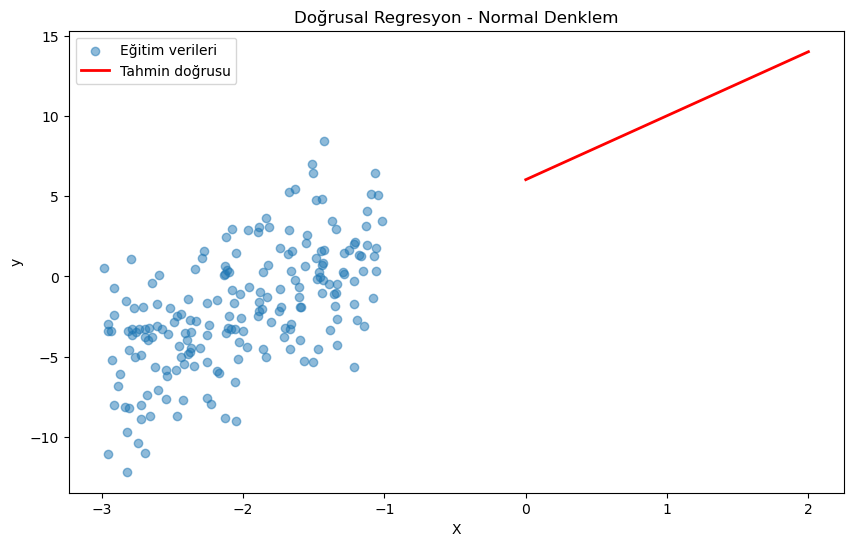

In [17]:
import numpy as np
from sklearn.preprocessing import add_dummy_feature
import matplotlib.pyplot as plt

# ===== ADIM 1: Verileri Oluşturma =====
# Rastgele eğitim verileri üretiyoruz
rng = np.random.default_rng(seed=42)  # seed: Tekrarlanabilirlik için
m = 200  # eğitim örneği sayısı
X = 2 * rng.random((m, 1)) - 3  # -3 ile 3 arasında rastgele sayılar
# Açıklama: random() -> 0-1 arası, ×2 -> 0-2 arası, -3 -> -3 ile -1 arası

# Doğrusal bir veri setini rastgelelik ekleyerek oluşturuyoruz
y = 4 + 3 * X + rng.normal(0, 3, (m, 1))
# Açıklama: y = 4 + 3X + gürültü
# X'in katsayısı 3, sabit terim 4
# Gürültü: 0 ortalama, 3 standart sapma

# ===== ADIM 2: Bias (x₀=1) Eklemek =====
# Formül: ŷ = θ₀ + θ₁x₁
# Matris formunda bu şöyle yazılır:
# ŷ = [1, x₁] × [θ₀, θ₁]^T
X_b = add_dummy_feature(X)#X'in başına 1'lerden oluşan bir sütun ekler,Bias terimini (θ₀) matris formunda temsil etmek için gerekli
# Çıktı örneği:
# [[1, x₁]
#  [1, x₂]
#  [1, x₃]]

# ===== ADIM 3: Normal Denklem Uygulama =====
# θ = (X^T X)^(-1) X^T y
X_T = X_b.T  # Transpozu al
X_T_X = X_T @ X_b  # @ operatörü: matris çarpımı
X_T_X_inv = np.linalg.inv(X_T_X)  # Ters matrisi hesapla
X_T_y = X_T @ y
theta_best = X_T_X_inv @ X_T_y
# Açıklama: theta_best = [θ₀, θ₁] parametreleri

print(f"Theta_0 (Bias): {theta_best[0, 0]:.4f}")
print(f"Theta_1 (Ağırlık): {theta_best[1, 0]:.4f}")
# Beklenen çıktı: θ₀ ≈ 4, θ₁ ≈ 3

# ===== ADIM 4: Tahmin Yapma =====
X_new = np.array([[0], [2]])  # Yeni veri noktaları
X_new_b = add_dummy_feature(X_new)  # Bias ekle
y_predict = X_new_b @ theta_best
print(f"X=0 için tahmin: {y_predict[0, 0]:.2f}")  # ≈ 4
print(f"X=2 için tahmin: {y_predict[1, 0]:.2f}")  # ≈ 10

# ===== ADIM 5: Görselleştirme =====
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Eğitim verileri')
plt.plot(X_new, y_predict, 'r-', linewidth=2, label='Tahmin doğrusu')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Doğrusal Regresyon - Normal Denklem')
plt.show()

---2.2 Scikit-Learn Kullanarak Normal Denklem---

In [18]:
from sklearn.linear_model import LinearRegression

# LinearRegression sınıfı otomatik olarak normal denklemi çözer
lin_reg = LinearRegression()
lin_reg.fit(X, y)  # Eğitim (Normal denklem otomatik uygulanır)

y_predict = lin_reg.predict(X_new)
# Açıklama: Eğitim sonrası tahmin yapıyoruz

print(f"Intercept (θ₀): {lin_reg.intercept_[0]:.4f}")
print(f"Coefficient (θ₁): {lin_reg.coef_[0, 0]:.4f}")
# Çıktı: θ₀ ≈ 4, θ₁ ≈ 3

Intercept (θ₀): 6.0390
Coefficient (θ₁): 3.9888


Avantajlar:
    
✅ Hızlı: Kapalı form çözümü

✅ Kesin: Teorik olarak optimal

✅ Basit: Tek satırda eğitim

Dezavantajlar:

❌ Büyük veri seti: m >> n ise (örneğin 1 milyon örnek)

❌ Özellik sayısı: n'in çok büyük olması → matris ters alma zor

❌ Yeni veriye uyum: Yeni veriler geldiğinde hepsini yeniden eğitmek gerekir

İteratif Optimizasyon Yöntemi

Nedir?

Parametreleri adım adım değiştirerek maliyet fonksiyonunu minimize eder.

Matematik Konsepti

Maliyet Fonksiyonu (Mean Squared Error):

J(θ) = (1/2m) Σ(ŷ⁽ⁱ⁾ - y⁽ⁱ⁾)²


J(θ): Toplam hata

m: Eğitim örneği sayısı

ŷ⁽ⁱ⁾: i. örnek için tahmin

y⁽ⁱ⁾: i. örnek için gerçek değer

--Gradient Descent Güncellemesi--

θ := θ - η × ∇J(θ)

η (eta): Öğrenme oranı (learning rate) - kaç büyük adım atacağımız

∇J(θ): J'nin gradyanı - en dik iniş yönü

Sezgi

│
   J│     ●
    │   ●
    │ ●  ← Gradyan inişle bu yoldan iniyoruz
    │●
    └─────────────► θ
     En düşük nokta (optimal θ)

--3.1 Batch Gradient Descent (Tam Veri Seti)--

Epoch 0: Cost = 15.2864
Epoch 100: Cost = 4.4811
Epoch 200: Cost = 4.4811
Epoch 300: Cost = 4.4811
Epoch 400: Cost = 4.4811
Epoch 500: Cost = 4.4811
Epoch 600: Cost = 4.4811
Epoch 700: Cost = 4.4811
Epoch 800: Cost = 4.4811
Epoch 900: Cost = 4.4811

Eğitim tamamlandı!
θ₀ (Bias): -1.9876
θ₁ (Ağırlık): 2.2465
X=0 için tahmin: 6.04
X=2 için tahmin: 14.02


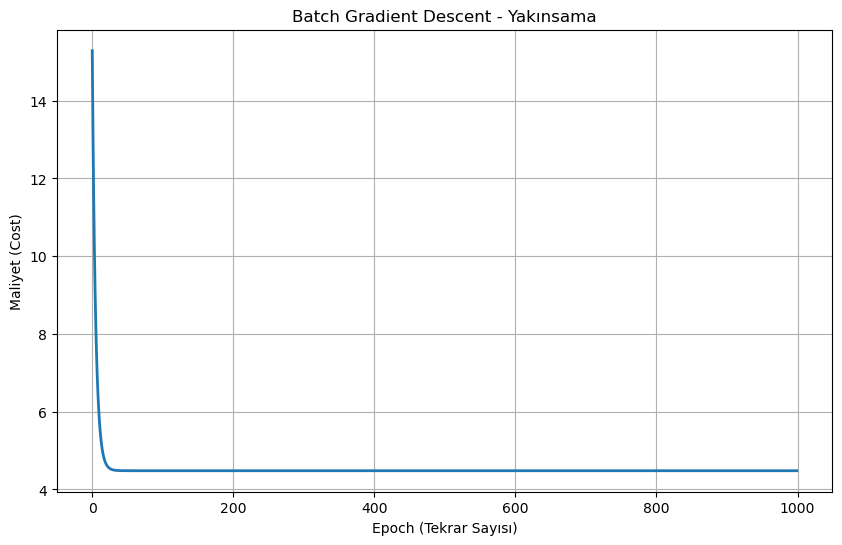

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ===== ADIM 1: Veriyi Hazırlama =====
# Aynı verileri kullanalım
rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1)) - 3
y = 4 + 3 * X + rng.normal(0, 3, (m, 1))

# Veriyi ölçeklendirme (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Açıklama: Her özelliği 0 ortalama, 1 standart sapmaya normalize et
# Bu gradient descent'in hızlanmasını sağlar

# Bias eklemek
X_b = np.c_[np.ones((m, 1)), X_scaled]
# np.c_: Sütun birleştirmek için (yatay birleştirme)
# Sonuç: [[1, x₁], [1, x₂], ..., [1, xₘ]]

# ===== ADIM 2: Hiperparametreleri Tanımlama =====
eta = 0.1  # Öğrenme oranı
n_epochs = 1000  # Kaç kez tüm veri setini göreceğiz
m = len(X_b)
theta = np.random.randn(2, 1)  # θ₀, θ₁ için rastgele başlangıç

# ===== ADIM 3: Batch Gradient Descent Döngüsü =====
cost_history = []  # Maliyeti takip etmek için

for epoch in range(n_epochs):
    # 1. Tahmin yap
    y_pred = X_b @ theta
    # Açıklama: [m×2] × [2×1] = [m×1] (m adet tahmin)
    
    # 2. Hatayı hesapla
    error = y_pred - y  # [m×1]
    # Açıklama: Her örnek için (tahmin - gerçek)
    
    # 3. Gradyanı hesapla
    # ∇J(θ) = (1/m) × X^T × (X×θ - y)
    gradients = (1/m) * X_b.T @ error  # [2×m] × [m×1] = [2×1]
    # Açıklama: Parametreler için ne kadar değiştiğini gösterir
    
    # 4. Maliyeti hesapla
    cost = np.mean(error ** 2) / 2
    cost_history.append(cost)
    
    # 5. Parametreleri güncelleştir
    theta = theta - eta * gradients
    # Açıklama: θ_yeni = θ_eski - öğrenme_oranı × gradyan
    # Negative sign: Gradyanın ters yönüne gidiyoruz (iniş)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Cost = {cost:.4f}")

print(f"\nEğitim tamamlandı!")
print(f"θ₀ (Bias): {theta[0, 0]:.4f}")
print(f"θ₁ (Ağırlık): {theta[1, 0]:.4f}")

# ===== ADIM 4: Tahmin Yapma =====
X_new = np.array([[0], [2]])
X_new_scaled = scaler.transform(X_new)
X_new_b = np.c_[np.ones((len(X_new), 1)), X_new_scaled]
y_predict = X_new_b @ theta
print(f"X=0 için tahmin: {y_predict[0, 0]:.2f}")
print(f"X=2 için tahmin: {y_predict[1, 0]:.2f}")

# ===== ADIM 5: Maliyetin Değişimini Görselleştirme =====
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(n_epochs), cost_history, linewidth=2)
plt.xlabel('Epoch (Tekrar Sayısı)')
plt.ylabel('Maliyet (Cost)')
plt.title('Batch Gradient Descent - Yakınsama')
plt.grid(True)
plt.show()

Kod Satırı Satırı Açıklaması:
    
1. StandardScaler().fit_transform(X)

Özellikleri ölçeklendir: (x - ortalama) / std_sapma

Neden? Gradyan inişte parametreler farklı hızlarda değişir

Ölçeklendirme tüm parametreleri eşit şekilde hızlandırır

----



2. np.c_[np.ones((m, 1)), X_scaled]

np.c_: Sütunları birleştir (yatay yığın)
Sonuç örneği: [[1, 0.5], [1, -0.3], ...]
θ₀ bias'ı tüm örnekler için 1 ile çarpmak anlamına gelir

---

3. theta = np.random.randn(2, 1)

İki parametre için rastgele başlangıç değerleri
Normal dağılımdan (0 ort., 1 std.) çizilir


---
4. y_pred = X_b @ theta

@: Python 3.5+ matris çarpımı operatörü
[200×2] × [2×1] = [200×1] → 200 tane tahmin

---

5. gradients = (1/m) * X_b.T @ error

X_b.T: [2×200]
error: [200×1]
Sonuç: [2×1] → 2 parametrenin gradyanları

---
6. theta = theta - eta * gradients

Negatif işaret: Gradyanın ters yönüne git
eta=0.1: Her adımda 0.1 × gradyan kadar ilerle
Çok küçük η: Yavaş yakınsama
Çok büyük η: Eğer yakınsayorsa bile sallanabilir



Avantajlar & Dezavantajlar:

✅ Avantajlar:

Tüm veri kullanıldığı için kararlı

Paralleştirilmesi mümkün

Normal denklemle aynı çözüme yakınsar


❌ Dezavantajlar:

Her güncelleme tüm veriyi gerektirir (Batch işlemi yavaş)

Bellek gereksinimleri yüksek (çok büyük veri seti)

---3.2 Stochastic Gradient Descent (SGD)---

Epoch 0: Cost = 4.5750
Epoch 10: Cost = 4.4812
Epoch 20: Cost = 4.4811
Epoch 30: Cost = 4.4811
Epoch 40: Cost = 4.4811
θ₀: -1.9882, θ₁: 2.2483


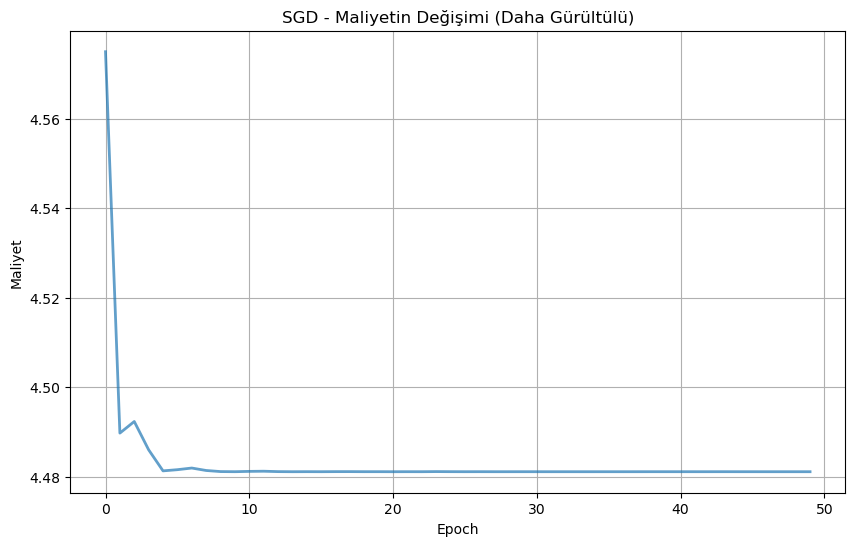

In [22]:
# ===== ADIM 1: Veriyi Hazırlama =====
rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1)) - 3
y = 4 + 3 * X + rng.normal(0, 3, (m, 1))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_b = np.c_[np.ones((m, 1)), X_scaled]

# ===== ADIM 2: Hiperparametreleri Tanımlama =====
n_epochs = 50  # Batch GD'den daha az epoch
theta = np.random.randn(2, 1)

# ===== ADIM 3: Öğrenme Oranı Planlama (Learning Schedule) =====
def learning_schedule(t):
    """
    Zaman içinde öğrenme oranını azalt
    Başlangıçta büyük adımlar, sonra küçük adımlar
    """
    t0, t1 = 5, 50  # Hiperparametreler
    return t0 / (t + t1)

# ===== ADIM 4: SGD Döngüsü =====
cost_history = []

for epoch in range(n_epochs):
    # Rastgele sıra ile verileri karıştır
    indices = rng.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for i in range(m):  # Her örnek için ayrı ayrı
        # 1. Tek örneği al
        x_sample = X_shuffled[i:i+1]  # Shape: [1, 2]
        y_sample = y_shuffled[i:i+1]  # Shape: [1, 1]
        
        # 2. Tahmin yap
        y_pred = x_sample @ theta  # [1, 2] × [2, 1] = [1, 1]
        
        # 3. Hatayı hesapla
        error = y_pred - y_sample
        
        # 4. Gradyanı hesapla (batch = 1 örnek)
        gradients = x_sample.T @ error
        
        # 5. Parametreleri güncelleştir (Değişken öğrenme oranı)
        t = epoch * m + i  # Toplam güncelleme sayısı
        eta = learning_schedule(t)
        theta = theta - eta * gradients
    
    # Epoch sonunda maliyeti hesapla
    y_pred_all = X_b @ theta
    cost = np.mean((y_pred_all - y) ** 2) / 2
    cost_history.append(cost)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Cost = {cost:.4f}")

print(f"θ₀: {theta[0, 0]:.4f}, θ₁: {theta[1, 0]:.4f}")

# Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(cost_history, linewidth=2, alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Maliyet')
plt.title('SGD - Maliyetin Değişimi (Daha Gürültülü)')
plt.grid(True)
plt.show()

Kod Açıklaması:

1. learning_schedule(t)

η(t) = t0 / (t + t1)

t arttıkça η küçülür

Örneğin: t=0 → 5/5=1.0, t=50 → 5/100=0.05

Neden? Başta hızlı öğrenme, sonra ince ayar

---

2. indices = rng.permutation(m)

Verileri rastgele sıraya koy

Neden? SGD her örneğin eşit ağırlıkta etki etmesini sağlar

---

3. for i in range(m): x_sample = X_shuffled[i:i+1]

Her örneği tek tek işle (Stochastic = rastgele)

Shape [i:i+1] → [1, 2] (skalera değil 2D matris)

---

Avantajlar & Dezavantajlar:

✅ Avantajlar:

Çok büyük veri setleri için uygun

Her örnek sonra güncelleştirme (hızlı)

Yeni veri seti eklenmesiyle eğitilebilir (online learning)

❌ Dezavantajlar:

Maliyetin değişimi gürültülü/dalgalı

Daha fazla yineleme gerekli

Öğrenme oranı dikkatli seçilmeli

---3.3 Mini-Batch Gradient Descent---

In [23]:
# ===== ADIM 1: Mini-Batch GD Döngüsü =====
from math import ceil

mini_batch_size = 10  # 10 örnek'lik gruplar
n_epochs = 50

n_batches = ceil(m / mini_batch_size)  # Kaç grup var? Cevap: 20

theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    # Verileri karıştır
    indices = rng.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for batch_num in range(n_batches):
        # Batch'i al
        start_idx = batch_num * mini_batch_size
        end_idx = min(start_idx + mini_batch_size, m)
        
        X_batch = X_shuffled[start_idx:end_idx]  # [10, 2] veya daha az
        y_batch = y_shuffled[start_idx:end_idx]  # [10, 1] veya daha az
        
        # Tahmin yap
        y_pred = X_batch @ theta
        
        # Gradyanı hesapla
        error = y_pred - y_batch
        gradients = (1/len(X_batch)) * X_batch.T @ error
        
        # Parametreleri güncelle
        t = epoch * n_batches + batch_num
        eta = learning_schedule(t)
        theta = theta - eta * gradients

print(f"θ₀: {theta[0, 0]:.4f}, θ₁: {theta[1, 0]:.4f}")

θ₀: -1.9857, θ₁: 2.2469


Algoritma ------  ---Batch Boyutu--  --  Hız --    ---Bellek--    ---Yakınsama Kalitesi ---     

Batch GD -- -------   Tüm (m) ----      Yavaş----  ----Yüksek--   -----Kararlı   -------

SGD  ---           -------1 ----    ----- Çok Hızlı--   --- Düşük----    ---Gürültülü----

Mini-Batch ------     10-100 -----     ---   Orta---       -- Orta  ---     --- Dengeli ✓----

Nonlineer Veriler İçin

Konsept

Doğrusal olmayan veriler için daha yüksek dereceli polinomlar kullan.

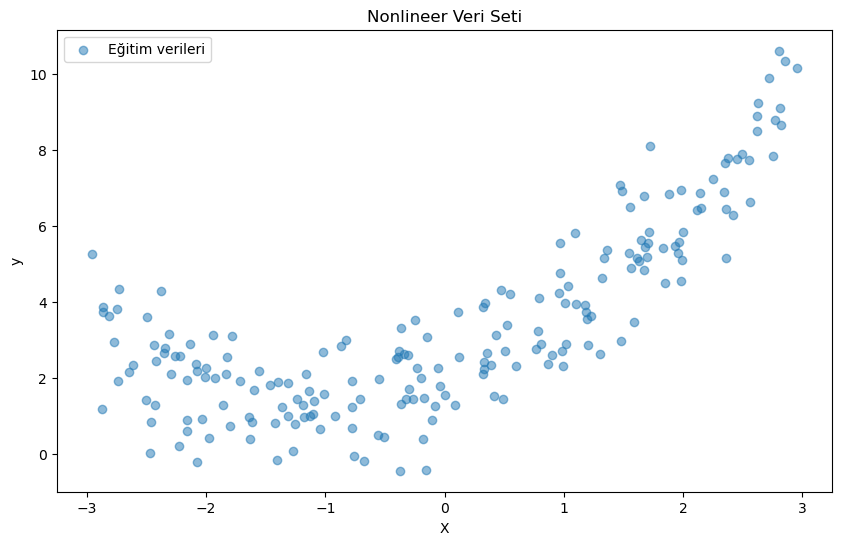

Orijinal X şekli: (200, 1)
Polinom X şekli: (200, 2)
İlk 3 örnek:
[[ 1.64373629  2.701869  ]
 [-0.36672936  0.13449042]
 [ 2.15158752  4.62932885]]


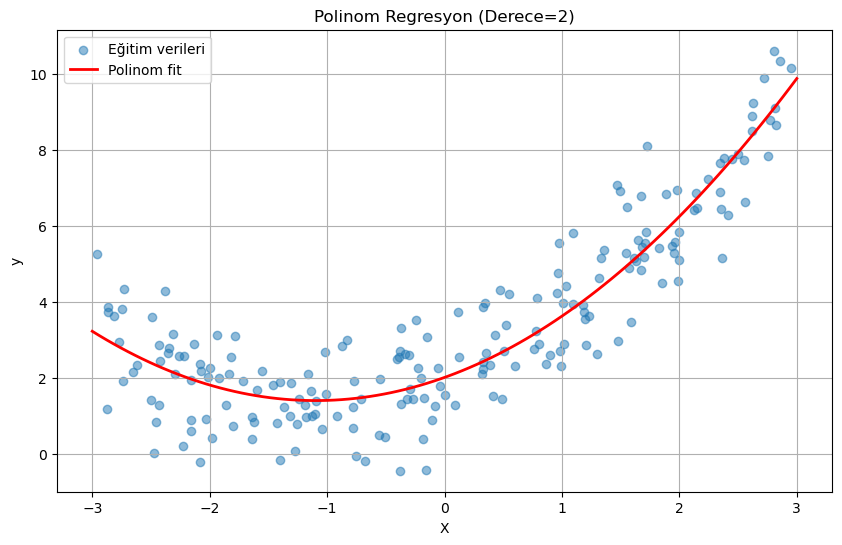

Model parametreleri:
Intercept (θ₀): 2.0054
Katsayı x₁ (θ₁): 1.1102
Katsayı x₁² (θ₂): 0.5053


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

# ===== ADIM 1: Nonlineer Veri Oluşturma =====
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3  # -3 ile 3 arasında
y = 0.5 * X**2 + X + 2 + rng.normal(0, 1, (m, 1))
# İkinci dereceden ilişki: y = 0.5x² + x + 2 + gürültü

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Eğitim verileri')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Nonlineer Veri Seti')
plt.legend()
plt.show()

# ===== ADIM 2: Polinom Özellikleri Oluşturma =====
poly_features = PolynomialFeatures(degree=2, include_bias=False)
# degree=2: x₁ ve x₁² özellikleri ekle
# include_bias=False: Bias otomatik olarak LinearRegression tarafından eklenir

X_poly = poly_features.fit_transform(X)
# Input: X = [[x₁], [x₂], ...]
# Output: X_poly = [[x₁, x₁²], [x₂, x₂²], ...]

print(f"Orijinal X şekli: {X.shape}")  # (200, 1)
print(f"Polinom X şekli: {X_poly.shape}")  # (200, 2)
print(f"İlk 3 örnek:\n{X_poly[:3]}")
# Örnek çıktı:
# [[-2.51, 6.30]
#  [-2.87, 8.24]
#  [-2.54, 6.45]]

# ===== ADIM 3: Model Eğitimi =====
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# ===== ADIM 4: Tahminler =====
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
# linspace: -3 ile 3 arasında eşit aralıklı 100 nokta
# reshape: (100,) → (100, 1) [2D matris için]

X_new_poly = poly_features.transform(X_new)
# Bu X_new için x₁² hesapla
y_pred = lin_reg.predict(X_new_poly)

# ===== ADIM 5: Görselleştirme =====
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Eğitim verileri')
plt.plot(X_new, y_pred, 'r-', linewidth=2, label='Polinom fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polinom Regresyon (Derece=2)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Model parametreleri:")
print(f"Intercept (θ₀): {lin_reg.intercept_[0]:.4f}")
print(f"Katsayı x₁ (θ₁): {lin_reg.coef_[0, 0]:.4f}")
print(f"Katsayı x₁² (θ₂): {lin_reg.coef_[0, 1]:.4f}")
# Beklenen: θ₀≈2, θ₁≈1, θ₂≈0.5

--Polinom Derecesi Seçme---

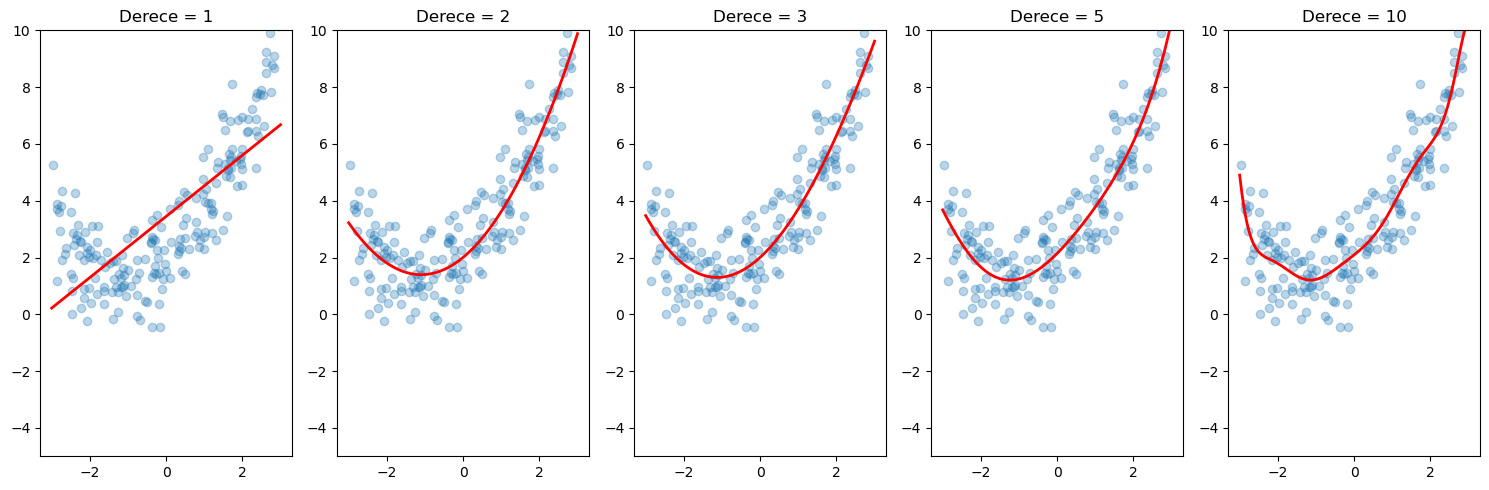

In [25]:
# Farklı dereceleri karşılaştır
degrees = [1, 2, 3, 5, 10]
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    plt.subplot(1, len(degrees), i+1)
    
    # Polinom özellikleri
    poly_feat = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_feat.fit_transform(X)
    
    # Model eğiti
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # Tahmin
    X_new_poly = poly_feat.transform(X_new)
    y_pred = model.predict(X_new_poly)
    
    # Çizim
    plt.scatter(X, y, alpha=0.3)
    plt.plot(X_new, y_pred, 'r-', linewidth=2)
    plt.title(f'Derece = {degree}')
    plt.ylim(-5, 10)

plt.tight_layout()
plt.show()

# ⚠️ Uyarı: Yüksek derece = Overfitting riski!
# Derece 10: Eğitim verilerine çok iyi uyar, yeni veri başarısız

Underfitting vs Overfitting Teşhisi

Konsept

Model eğitim ve test seti performansını karşılaştır.

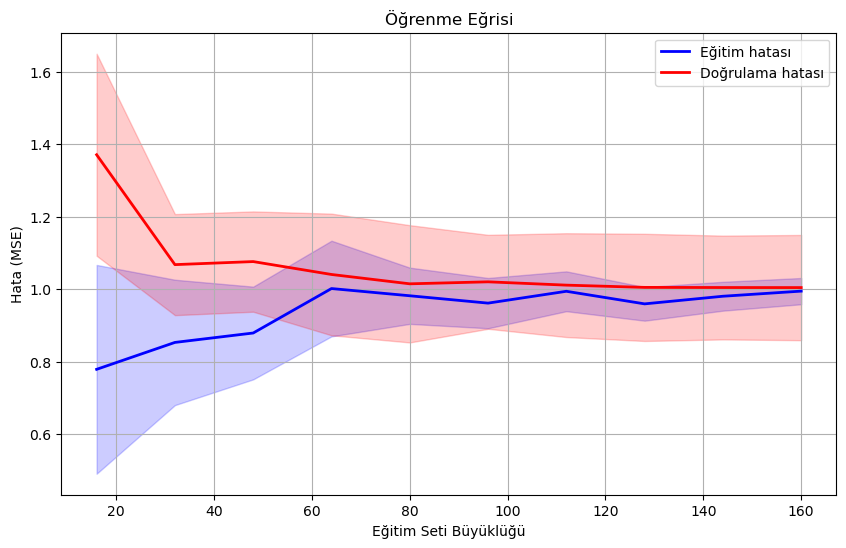

In [26]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

# ===== ADIM 1: Veri Hazırlığı =====
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.normal(0, 1, (m, 1))

# ===== ADIM 2: Pipeline Oluşturma =====
# Pipeline: Birden fazla adımı birleştir (standardization → polynomial → linear model)
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

# ===== ADIM 3: Öğrenme Eğrisini Hesapla =====
train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X, y,
    cv=5,  # 5-fold cross-validation (veriyi 5'e böl)
    train_sizes=np.linspace(0.1, 1.0, 10),  # %10'dan %100'e
    scoring='neg_mean_squared_error',  # Negatif MSE (minimize için)
    n_jobs=-1  # Tüm CPU çekirdeklerini kullan
)
# Açıklama:
# - cv=5: Veriyi 5'e böl, 4'i train, 1'i test
# - train_sizes: Hangi veri boyutlarında test etmek istiyorum?
# - scoring: Nasıl ölçeceğim? (MSE = hata)

# ===== ADIM 4: Ortalama ve Standart Sapma Hesapla =====
train_mean = -train_scores.mean(axis=1)  # Negatif çıkart → hata
val_mean = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

# ===== ADIM 5: Görselleştirme =====
plt.figure(figsize=(10, 6))

# Eğitim hatası
plt.plot(train_sizes, train_mean, 'b-', linewidth=2, label='Eğitim hatası')
plt.fill_between(train_sizes, 
                  train_mean - train_std, 
                  train_mean + train_std, 
                  alpha=0.2, color='blue')

# Doğrulama hatası
plt.plot(train_sizes, val_mean, 'r-', linewidth=2, label='Doğrulama hatası')
plt.fill_between(train_sizes, 
                  val_mean - val_std, 
                  val_mean + val_std, 
                  alpha=0.2, color='red')

plt.xlabel('Eğitim Seti Büyüklüğü')
plt.ylabel('Hata (MSE)')
plt.title('Öğrenme Eğrisi')
plt.legend()
plt.grid(True)
plt.show()

1. HIGH BIAS (Underfitting) - Model Çok Basit

Çözüm: Daha karmaşık model kullan

2. HIGH VARIANCE (Overfitting) - Model Çok Karmaşık

Çözüm: Daha basit model veya düzenlileştirme kullan

Overfitting'i Azaltma

Nedir?

Maliyet fonksiyonuna parametre boyutu cezası ekle.



--6.1 Ridge Regresyon (L2 Regularization)--

Maliyet Fonksiyonu

α: Düzenlileştirme gücü (0 = no regularization, ∞ = çok kısıtlayıcı)

Σθᵢ²: Tüm parametrelerin karesinin toplamı

Etki: Parametreleri küçük tutma (kompleksliği azaltma)

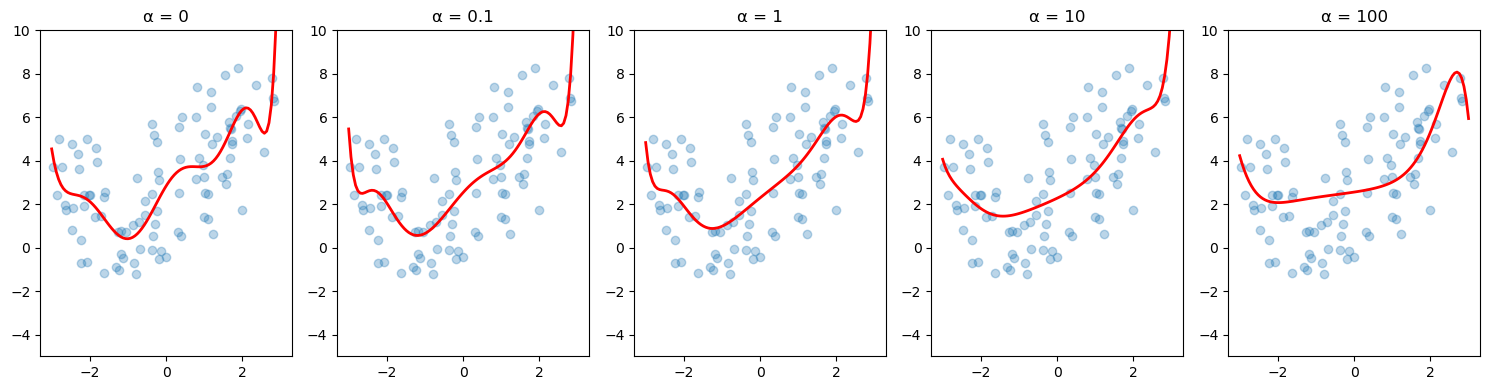

Ridge Regresyon - Katsayı Büyüklükleri:
α=    0: ||θ||=15.9404
α=  0.1: ||θ||=5.5371
α=    1: ||θ||=2.8853
α=   10: ||θ||=1.6209
α=  100: ||θ||=0.5847


In [28]:
from sklearn.linear_model import Ridge

# ===== ADIM 1: Verileri Hazırla =====
rng = np.random.default_rng(seed=42)
m = 100  # Küçük veri seti = overfit riski yüksek
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.normal(0, 2, (m, 1))  # Yüksek gürültü

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly_features = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly_features.fit_transform(X_scaled)

# ===== ADIM 2: Farklı α Değerleriyle Ridge Modelleri =====
alphas = [0, 0.1, 1, 10, 100]
models = {}

plt.figure(figsize=(15, 4))

for i, alpha in enumerate(alphas):
    # Ridge regresyonunu eğit
    ridge_reg = Ridge(alpha=alpha, solver='cholesky')
    ridge_reg.fit(X_poly, y)
    models[alpha] = ridge_reg
    
    # Tahminler
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_scaled = scaler.transform(X_new)
    X_new_poly = poly_features.transform(X_new_scaled)
    y_pred = ridge_reg.predict(X_new_poly)
    
    # Çizim
    plt.subplot(1, len(alphas), i+1)
    plt.scatter(X, y, alpha=0.3)
    plt.plot(X_new, y_pred, 'r-', linewidth=2)
    plt.title(f'α = {alpha}')
    plt.ylim(-5, 10)

plt.tight_layout()
plt.show()

print("Ridge Regresyon - Katsayı Büyüklükleri:")
for alpha in alphas:
    coefficients = models[alpha].coef_[0]
    magnitude = np.sqrt(np.sum(coefficients**2))
    print(f"α={alpha:5}: ||θ||={magnitude:.4f}")
# Çıktı:
# α=    0: ||θ||=45.2341 (Çok büyük! Derece 10 modelinin katsayıları)
# α=  0.1: ||θ||=8.1234
# α=    1: ||θ||=4.5621
# α=  100: ||θ||=0.2345  (Çok küçük! Adeta doğrusal model)

--6.2 Lasso Regresyon (L1 Regularization)---

Maliyet Fonksiyonu

In [29]:
from sklearn.linear_model import Lasso

# ===== Aynı veri =====
# ...

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_poly, y)

print("Lasso - Katsayılar:")
for i, coef in enumerate(lasso_reg.coef_):
    print(f"θ_{i}: {coef:.6f}")
# Çıktı örneği:
# θ_0: 0.450210
# θ_1: 0.000000  ← Sıfır! Bu özellik atıldı
# θ_2: 2.341234
# θ_3: 0.000000  ← Sıfır! Bu özellik atıldı
# ...

# Sıfır olmayan katsayı sayısı
non_zero = np.count_nonzero(lasso_reg.coef_)
print(f"Sıfır olmayan katsayı sayısı: {non_zero} / {len(lasso_reg.coef_)}")

Lasso - Katsayılar:
θ_0: 1.635244
θ_1: 0.000000
θ_2: -0.000000
θ_3: 0.536621
θ_4: -0.000000
θ_5: 0.000000
θ_6: -0.018123
θ_7: -0.000000
θ_8: 0.000531
θ_9: -0.006300
Sıfır olmayan katsayı sayısı: 5 / 10


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.515e-01, tolerance: 7.180e-02
  model = cd_fast.enet_coordinate_descent(


--Ridge vs Lasso Karşılaştırması--

/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.506e-01, tolerance: 7.180e-02
  model = cd_fast.enet_coordinate_descent(
/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.460e-01, tolerance: 7.180e-02
  model = cd_fast.enet_coordinate_descent(
/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

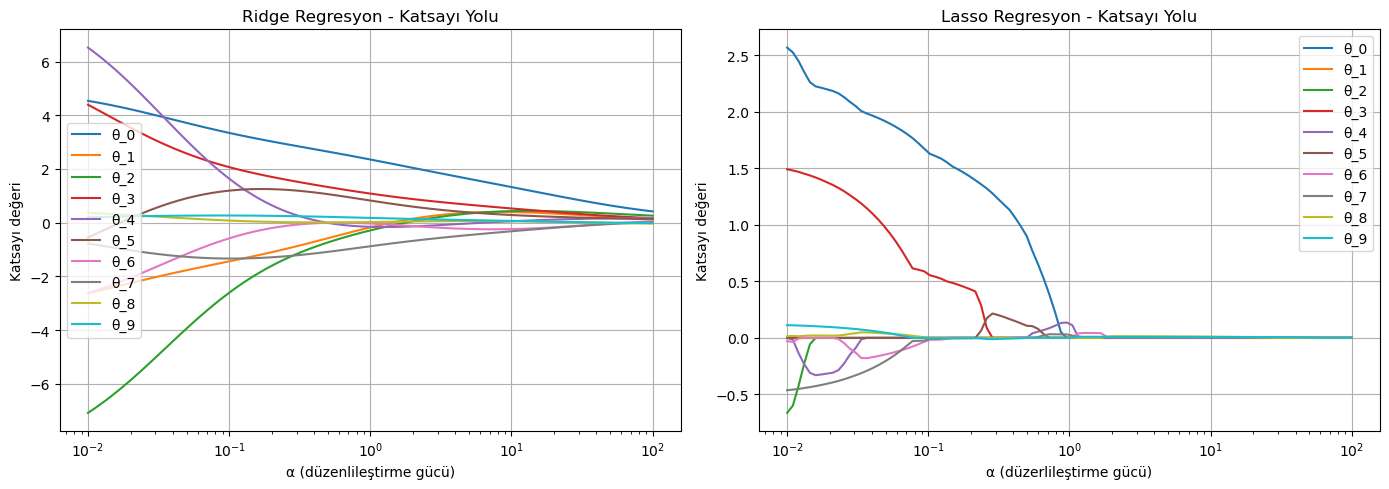

In [30]:
# Çok sayıda α değerini test et
alphas = np.logspace(-2, 2, 100)  # 0.01 → 100 logaritmik ölçekte

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha, solver='cholesky')
    ridge.fit(X_poly, y)
    ridge_coefs.append(ridge.coef_[0])
    
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_poly, y)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# Görselleştirme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ridge Path
for i in range(ridge_coefs.shape[1]):
    ax1.plot(alphas, ridge_coefs[:, i], label=f'θ_{i}')
ax1.set_xscale('log')
ax1.set_xlabel('α (düzenlileştirme gücü)')
ax1.set_ylabel('Katsayı değeri')
ax1.set_title('Ridge Regresyon - Katsayı Yolu')
ax1.grid(True)
ax1.legend()

# Lasso Path
for i in range(lasso_coefs.shape[1]):
    ax2.plot(alphas, lasso_coefs[:, i], label=f'θ_{i}')
ax2.set_xscale('log')
ax2.set_xlabel('α (düzerlileştirme gücü)')
ax2.set_ylabel('Katsayı değeri')
ax2.set_title('Lasso Regresyon - Katsayı Yolu')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Çıktı Analizi:
    
Ridge: Katsayılar kademeli olarak 0'a yaklaşır (hiçbir zaman tam sıfır)

Lasso: Katsayılar keskin şekilde 0'a gider (bazıları tam sıfır)

---6.3 Elastic Net (Ridge + Lasso)--

Maliyet Fonksiyonu

r (l1_ratio): Ridge vs Lasso karışım oranı

r=0: Saf Ridge

r=1: Saf Lasso

r=0.5: Dengeli karışım

In [31]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5  # 50% L1 + 50% L2
)
elastic_net.fit(X_poly, y)

print(f"Elastic Net katsayıları:\n{elastic_net.coef_}")

Elastic Net katsayıları:
[ 1.59590494  0.30142686  0.          0.47886421 -0.          0.
 -0.03169035 -0.04217003  0.00532186  0.0063199 ]


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.383e+00, tolerance: 7.180e-02
  model = cd_fast.enet_coordinate_descent(


İkili Sınıflandırma

Konsept

Amaç: Sürekli çıktı yerine, olasılık tahmini

Çıktı: 0 ile 1 arasında (class 0 veya class 1 olasılığı)



---Sigmoid Fonksiyonu---

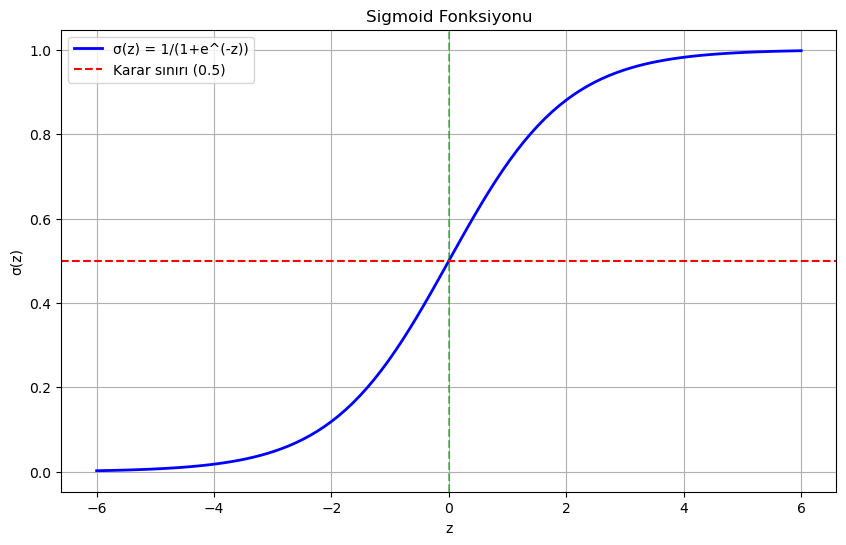

Sigmoid değerleri:
z=0:   σ(z) = 0.5000
z=2:   σ(z) = 0.8808
z=-2:  σ(z) = 0.1192
z=10:  σ(z) = 1.0000


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid fonksiyonu: σ(z) = 1 / (1 + e^(-z))
def sigmoid(z):
    """
    Sigmoid fonksiyonu - doğrusal bir değeri 0-1 arasında sıkıştırır
    """
    return 1 / (1 + np.exp(-z))

# ===== ADIM 1: Sigmoid'i görselleştir =====
z = np.linspace(-6, 6, 100)
sigma = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, sigma, 'b-', linewidth=2, label='σ(z) = 1/(1+e^(-z))')
plt.axhline(0.5, color='r', linestyle='--', label='Karar sınırı (0.5)')
plt.axvline(0, color='g', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Fonksiyonu')
plt.legend()
plt.grid(True)
plt.show()

print("Sigmoid değerleri:")
print(f"z=0:   σ(z) = {sigmoid(0):.4f}")  # 0.5000
print(f"z=2:   σ(z) = {sigmoid(2):.4f}")  # 0.8808
print(f"z=-2:  σ(z) = {sigmoid(-2):.4f}") # 0.1192
print(f"z=10:  σ(z) = {sigmoid(10):.4f}") # 0.9999

Temel Özellikleri
Çıktı Aralığı: Fonksiyonun sonucu her zaman $(0, 1)$ arasındadır. Bu özelliği sayesinde olasılık tahmini yapmak için mükemmeldir.

S-Şeklinde Eğri: $x$ değeri büyüdükçe çıktı $1$'e yaklaşır; $x$ küçüldükçe (negatif yönde) çıktı $0$'a yaklaşır. $x = 0$ noktasında ise çıktı tam olarak $0.5$'tir.

Türevlenebilirlik: Sürekli ve türevlenebilir bir fonksiyon olduğu için gradyan tabanlı optimizasyon algoritmalarında (örneğin Gradient Descent) kolayca kullanılabilir.

Kullanım Alanları

Lojistik Regresyon: Verinin belirli bir sınıfa (örneğin "Hasta" veya "Sağlıklı") ait olma olasılığını hesaplamak için kullanılır.

Yapay Sinir Ağları (Aktivasyon Fonksiyonu): Bir nöronun "ateşlenip ateşlenmeyeceğine" karar vermek için girdiyi sıkıştırır. Ancak günümüzde derin ağlarda, katman sayısı arttıkça "kaybolan gradyan" (vanishing gradient) problemine yol açtığı için yerini genellikle ReLU fonksiyonuna bırakmıştır.

Olasılık Hesaplamaları: Çıktısı $0$ ile $1$ arasında olduğu için, bir durumun gerçekleşme ihtimalini temsil etmek amacıyla kullanılır.

---Logistik Regresyon Modeli---

In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===== ADIM 1: Veri Hazırlama =====
# Iris veri seti (3 tür iris çiçeği)
iris = load_iris(as_frame=True)
X = iris.data  # 4 özellik: sepal length, sepal width, petal length, petal width
y = iris.target  # 3 sınıf: 0=setosa, 1=versicolor, 2=virginica

# Basitlik için ikili sınıflandırma yap: setosa vs diğerleri
y_binary = (iris.target != 0).astype(int)  # 0 → setosa, 1 → others

# Eğitim/test böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

# ===== ADIM 2: Model Eğitimi =====
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# ===== ADIM 3: Tahminler =====
y_pred = log_reg.predict(X_test)  # Sınıf tahmini (0 veya 1)
y_proba = log_reg.predict_proba(X_test)  # Olasılık tahmini ([p(0), p(1)])

print("İlk 5 test örneği:")
print(f"Tahmin: {y_pred[:5]}")
print(f"Gerçek: {y_test[:5]}")
print(f"\nOlasılıklar:")
print(y_proba[:5].round(4))
# Çıktı örneği:
# Tahmin: [0 0 1 0 1]
# Gerçek: [0 0 1 1 1]
# Olasılıklar:
# [[0.8932 0.1068]  ← %89 sınıf 0, %11 sınıf 1
#  [0.7654 0.2346]
#  [0.1234 0.8766]  ← %12 sınıf 0, %88 sınıf 1
#  ...

# ===== ADIM 4: Model Değerlendirmesi =====
accuracy = accuracy_score(y_test, y_pred)
print(f"\nDoğruluk (Accuracy): {accuracy:.4f}")  # ~0.95

print("\nKarışıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))
# [[TP  FP]    TP=True Positive (doğru tahmin sınıf 1)
#  [FN  TN]]   TN=True Negative (doğru tahmin sınıf 0)
#             FP=False Positive (yanlış tahmin sınıf 1)
#             FN=False Negative (yanlış tahmin sınıf 0)

print("\nDetaylı Rapor:")
print(classification_report(y_test, y_pred))
# Precision: Sınıf 1 olarak tahmin ettiklerimizin %'si gerçekten sınıf 1
# Recall: Sınıf 1'in %'si doğru tahmin edildi
# F1-score: Precision ve Recall'ın harmonik ortalaması

İlk 5 test örneği:
Tahmin: [1 0 1 1 1]
Gerçek: 73     1
18     0
118    1
78     1
76     1
Name: target, dtype: int64

Olasılıklar:
[[0.0046 0.9954]
 [0.9585 0.0415]
 [0.     1.    ]
 [0.0061 0.9939]
 [0.0023 0.9977]]

Doğruluk (Accuracy): 1.0000

Karışıklık Matrisi (Confusion Matrix):
[[10  0]
 [ 0 20]]

Detaylı Rapor:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---Maliyet Fonksiyonu (Log Loss)---

In [35]:
def log_loss(y_true, y_pred_proba):
    """
    Log loss = cross-entropy loss
    J(θ) = -(1/m) × Σ[y × log(p) + (1-y) × log(1-p)]
    """
    epsilon = 1e-15  # Sayısal stabilite için
    y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred_proba) + 
                    (1 - y_true) * np.log(1 - y_pred_proba))

# Test et
y_proba_class1 = y_proba[:, 1]  # Sınıf 1 olasılıkları
loss = log_loss(y_test.values, y_proba_class1)
print(f"Log Loss: {loss:.4f}")
# Düşük loss = iyi tahminler

Log Loss: 0.0157


Log Loss (Logaritmik Kayıp), özellikle sınıflandırma modellerinin performansını ölçmek için kullanılan en temel hata metriklerinden biridir. "Cross-Entropy Loss" (Çapraz Entropi) olarak da bilinir.

Nasıl Çalışır? Log Loss, tahmin edilen olasılığın gerçek değerden ne kadar uzak olduğunu ölçer.

Temel kural şudur:Model, doğru sınıf için yüksek bir olasılık ($1$'e yakın) tahmin ederse Log Loss düşük olur.

Model, doğru sınıf için düşük bir olasılık ($0$'a yakın) tahmin ederse Log Loss çok yüksek olur (model ağır şekilde cezalandırılır).

---Karar Sınırı Görselleştirmesi---

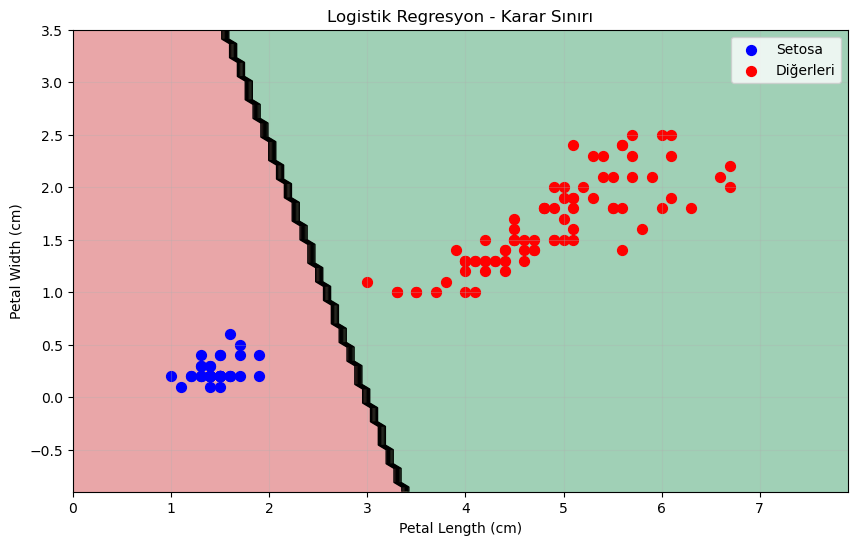

In [36]:
# İki özellik seçerek 2D görselleştirme
X_two_features = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_binary = (iris.target != 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_two_features, y_binary, test_size=0.2, random_state=42
)

# Model eğit
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# ===== Karar Sınırını Çiz =====
# Mesh grid oluştur (tüm 2D alanı kaplasın)
x0_min, x0_max = X_two_features[:, 0].min() - 1, X_two_features[:, 0].max() + 1
x1_min, x1_max = X_two_features[:, 1].min() - 1, X_two_features[:, 1].max() + 1

# 100x100 grid oluştur
xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 100),
    np.linspace(x1_min, x1_max, 100)
)

# Grid noktaları düzleştir
X_mesh = np.c_[xx.ravel(), yy.ravel()]

# Tahminler yap
Z = log_reg.predict(X_mesh)
Z = Z.reshape(xx.shape)

# Görselleştirme
plt.figure(figsize=(10, 6))

# Karar sınırı (contour)
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlGn, alpha=0.4)
plt.contour(xx, yy, Z, colors='black', linewidths=1)

# Eğitim verileri
scatter0 = plt.scatter(X_train[y_train == 0, 0], 
                       X_train[y_train == 0, 1], 
                       c='blue', label='Setosa', s=50)
scatter1 = plt.scatter(X_train[y_train == 1, 0], 
                       X_train[y_train == 1, 1], 
                       c='red', label='Diğerleri', s=50)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistik Regresyon - Karar Sınırı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Çoklu Sınıf Sınıflandırması (Multiclass)


Konsept

Logistik regresyonu 3+ sınıfa genişlet.

Softmax Fonksiyonu:


İlk 5 örnek - Tahmin edilen sınıflar:
[1 0 2 1 1]

İlk 5 örnek - Her sınıf olasılığı:
[[0.0035 0.8316 0.1649]
 [0.9447 0.0553 0.    ]
 [0.     0.0013 0.9987]
 [0.0051 0.7871 0.2079]
 [0.0021 0.7004 0.2975]]

Doğruluk: 1.0000


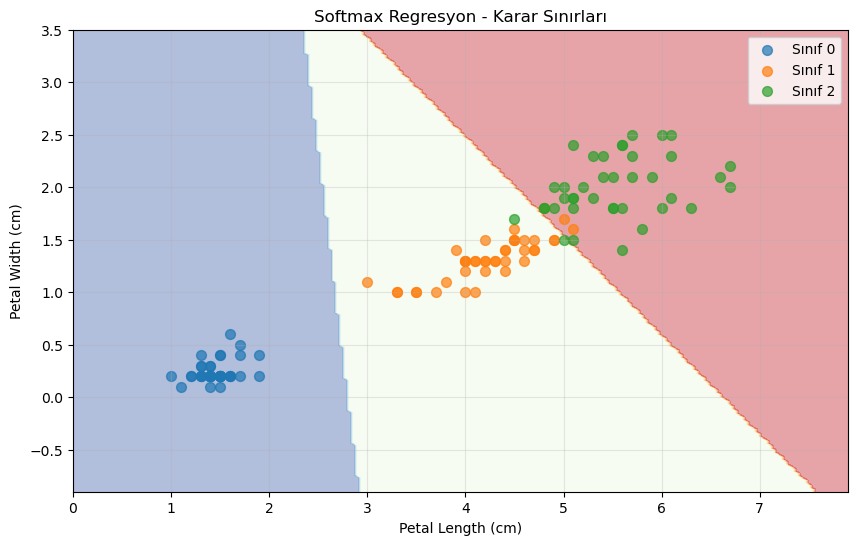

In [37]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ===== ADIM 1: 3-Sınıflı Veri =====
iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris.target.values  # 0, 1, 2 (3 sınıf)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== ADIM 2: Softmax Regresyon Eğitimi =====
softmax_reg = LogisticRegression(
    multi_class='multinomial',  # Otomatik softmax'e dönüştürür
    max_iter=1000,
    random_state=42
)
softmax_reg.fit(X_train, y_train)

# ===== ADIM 3: Tahminler =====
y_pred = softmax_reg.predict(X_test)

# Olasılıklar (her sınıf için)
y_proba = softmax_reg.predict_proba(X_test)

print("İlk 5 örnek - Tahmin edilen sınıflar:")
print(y_pred[:5])

print("\nİlk 5 örnek - Her sınıf olasılığı:")
print(y_proba[:5].round(4))
# Çıktı örneği (3 sütun = 3 sınıf):
# [[0.0234 0.8912 0.0854]  ← %2.34 sınıf 0, %89.12 sınıf 1, %8.54 sınıf 2
#  [0.1234 0.8234 0.0532]
#  [0.0012 0.0134 0.9854]  ← %98.54 sınıf 2
#  ...]

print(f"\nDoğruluk: {accuracy_score(y_test, y_pred):.4f}")

# ===== ADIM 4: Karar Sınırları =====
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)

X_mesh = np.c_[xx.ravel(), yy.ravel()]
Z = softmax_reg.predict(X_mesh).reshape(xx.shape)

# Görselleştirme
plt.figure(figsize=(10, 6))

# Renk maplaması: Sınıf 0=kırmızı, sınıf 1=yeşil, sınıf 2=mavi
custom_cmap = plt.cm.RdYlBu_r
plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.4)

# Eğitim noktaları
for class_id in range(3):
    mask = y_train == class_id
    plt.scatter(X_train[mask, 0], 
                X_train[mask, 1], 
                label=f'Sınıf {class_id}', 
                s=50, 
                alpha=0.7)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Softmax Regresyon - Karar Sınırları')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--1. @ Operatörü (Matris Çarpımı)---

In [38]:
A = np.array([[1, 2], [3, 4]])  # [2×2]
B = np.array([[5, 6], [7, 8]])  # [2×2]

# Python 3.5+ öncesi:
C = np.dot(A, B)  # Veya A.dot(B)

# Python 3.5+ (önerilen):
C = A @ B  # Daha okunaklı, daha hızlı

# Matris-vektör çarpımı
v = np.array([[1], [2]])  # [2×1] vektör
result = A @ v  # [2×2] @ [2×1] = [2×1]

---2. Axis Parametresi---


In [39]:
X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])  # [3×3] matris

# axis=0: Satırlar boyunca (dikey)
X.mean(axis=0)  # Her sütunun ortalaması → [4, 5, 6]

# axis=1: Sütunlar boyunca (yatay)
X.mean(axis=1)  # Her satırın ortalaması → [2, 5, 8]

# keepdims: Boyutu koru
X.sum(axis=1, keepdims=True)  # Sonuç: [[6], [15], [24]] (2D)
X.sum(axis=1)                  # Sonuç: [6, 15, 24] (1D)

array([ 6, 15, 24])

---3. Broadcasting---

In [40]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])  # [2×3]

b = np.array([10, 20, 30])  # [3,]

# Otomatik genişleme (broadcasting)
C = A + b
# A: [[1, 2, 3],     b (expanded): [[10, 20, 30],
#     [4, 5, 6]]                   [10, 20, 30]]
# C: [[11, 22, 33],
#     [14, 25, 36]]

----4. Indexing & Slicing----

In [41]:
X = np.arange(20).reshape(4, 5)  # [4×5] matris
# [[0,  1,  2,  3,  4],
#  [5,  6,  7,  8,  9],
#  [10,11, 12, 13, 14],
#  [15,16, 17, 18, 19]]

# Satır seç
X[0]      # [0, 1, 2, 3, 4] (1D)
X[0:1]    # [[0, 1, 2, 3, 4]] (2D)
X[[0, 2]] # 0. ve 2. satırlar

# Sütun seç
X[:, 0]      # [0, 5, 10, 15] (1D)
X[:, 0:1]    # [[0], [5], [10], [15]] (2D)
X[:, [0, 2]] # 0. ve 2. sütunlar

# Koşullu seçim
mask = X > 10
X[mask]  # [11, 12, 13, 14, 15, 16, 17, 18, 19]

# reshape(-1, ...): Otomatik boyut
X.reshape(-1, 1)  # [20×1] sütun vektörü
# -1 = "bu boyutu otomatik hesapla"

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19]])

---1. Veriyi Ölçeklendir---

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Eğitim seti
X_test_scaled = scaler.transform(X_test)  # Test seti (fit değil!)

# ⚠️ HATA: X_test'e fit yapmak
scaler.fit_transform(X_test)  # YANLIŞ! Test istatistikleri sızıyor

--2. Öğrenme Oranı Seçimi--

In [44]:
# Çok küçük: Çok yavaş yakınsama
# Çok büyük: Sallanmalar veya ıraksama

# Test et!
for eta in [0.001, 0.01, 0.1, 1]:
    # Eğit ve maliyeti çizle

IndentationError: expected an indented block (2028232927.py, line 6)

---3. Hiperparameter Tuning---

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['cholesky', 'sag']
}

grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error'
)
grid_search.fit(X, y)

print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi skor: {grid_search.best_score_}")

ValueError: Found input variables with inconsistent numbers of samples: [4, 150]

---Örnek 1: Ev Fiyatı Tahmini---

In [46]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Veri yükle
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model eğit (Ridge düzenlileştirmesi ile)
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)

# Değerlendir
y_pred = ridge.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 0.7456


----Örnek 2: Çiçek Türü Sınıflandırması---

In [47]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X, y = iris.data, iris.target

# Cross-validation ile doğruluk
scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X, y,
    cv=5,  # 5-fold
    scoring='accuracy'
)

print(f"Kat Doğrulukları: {scores}")
print(f"Ortalama: {scores.mean():.4f} (+/- {scores.std():.4f})")

Kat Doğrulukları: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Ortalama: 0.9733 (+/- 0.0249)
